# Implementing Approach

In the following sections, I will perform implement the approach proposed in stage 3, which consists of:

1. Removing "label 2" examples from the original dataset as they are cases of borderline PCL which even human annotators were unable to agree on. Thus, forcing it into any one class is likely to just introduce noise into the dataset. As shown in the EDA, they also only 1.38% of the dataset, and thus can be removed without sacrificing data quantity. This removal and classification of the remaining data into binary 0/1 No-PCL / PCL labels has been done in `data/filtered_pcl_task_data.csv`.

2. Class weighting: In the model's loss function, there will be greater weightage assigned to the misclassification of PCL examples, forcing the model to optimise for detecting patterns within PCL. As our primary metric is F1-score, this will likely be achieved by performing a weighted-average of the F1 scores of both classes, skewed more toward the PCL side.

3. Performing Layer-wise Learning Rate Decay (LLRD) within the RoBERTa fine-tuning.

4. Performing threshold-tuning -> using the validation set to determine the optimal decision boundary threshold. 

In [7]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [8]:
import pandas as pd 
import numpy as np 
import spacy
import matplotlib
import transformers
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import torch
import torch.nn as nn

In [9]:
from transformers import AutoModelForSequenceClassification

MODEL = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=1
)

SEED = 42
AUGMENT = True

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 936.14it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [10]:
DATA_FOLDER_PATH = "../data" 
DATASET_PATH = f"{DATA_FOLDER_PATH}/filtered_pcl_task_data.csv"

data = pd.read_csv(DATASET_PATH)
data.head()

# We have a Null value, hence we drop it 
null_values = data[["text", "label"]].isnull().sum() > 0
print(null_values)
if null_values.any():
    data = data.dropna(subset=["text", "label"]).reset_index(drop=True)

text      True
label    False
dtype: bool


In [11]:
# Splitting data into train and dev sets
TRAIN_PATH = f"{DATA_FOLDER_PATH}/train_semeval_parids-labels.csv"
DEV_PATH = f"{DATA_FOLDER_PATH}/dev_semeval_parids-labels.csv"
DATASET_FEATURES = ["id", "text", "label"]

train_df = pd.read_csv(TRAIN_PATH)
dev_df = pd.read_csv(DEV_PATH)

train_data = data[data["id"].isin(train_df["par_id"])][DATASET_FEATURES]
val_data = data[data["id"].isin(dev_df["par_id"])][DATASET_FEATURES]

# Validate we have both labels in both sets
assert(train_data["label"].nunique() == 2 and val_data["label"].nunique() == 2)

train_data.to_csv(f"{DATA_FOLDER_PATH}/train_data.csv")
val_data.to_csv(f"{DATA_FOLDER_PATH}/val_data.csv")

display(train_data.head())
display(val_data.head())

,id,text,label
0,1,"We 're living in times of absolute insanity , ...",0
1,2,"In Libya today , there are countless number of...",0
2,3,White House press secretary Sean Spicer said t...,0
3,4,Council customers only signs would be displaye...,0
4,5,""" Just like we received migrants fleeing El Sa...",0


,id,text,label
105,107,"His present "" chambers "" may be quite humble ,...",1
148,151,10:41am - Parents of children who died must ge...,1
151,154,When some people feel causing problem for some...,1
154,157,We are alarmed to learn of your recently circu...,1
182,187,""" We share a global responsibility to respond ...",1


In [ ]:
import os
from BestModel.backtranslation import backtranslate, substitute_words

# Flag set to toggle data augmentation on/off
if AUGMENT:
    # Add augmentations to training dataset ONLY. This is to ensure no data leakage from train -> val/test set.
    train_data1 = train_data[train_data["label"] == 1].reset_index(drop=True)
    texts = train_data1["text"].tolist()
    labels = train_data1["label"].tolist()

    BT_FILEPATH = f"{DATA_FOLDER_PATH}/train_backtranslate.csv"
    SUB_FILEPATH = f"{DATA_FOLDER_PATH}/train_cwe_bert.csv"

    if not os.path.exists(BT_FILEPATH):
        bt_data = backtranslate(texts, labels, BT_FILEPATH)
    else:
        bt_data = pd.read_csv(BT_FILEPATH)

    if not os.path.exists(SUB_FILEPATH):
        sub_data = substitute_words(texts, labels, SUB_FILEPATH)
    else:
        sub_data = pd.read_csv(SUB_FILEPATH)

    # Appending augmented data into original training data
    train_data = pd.concat([train_data, bt_data, sub_data], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(train_data.shape)
    train_data.head()

ImportError: attempted relative import with no known parent package

okay give me the code to do this fine tuning from start to end. I want:
 - Class weighting (proportional to sqrt of PCL : no-PCL ratio)
 - LLRD
 - RoBERTa-base model


In [ ]:
# Determine class imbalance and weights to apply

train_labels = train_data["label"].values
n_neg = np.sum(train_labels == 0)
n_pos = np.sum(train_labels == 1)

print(f"Non-PCL: {n_neg}, PCL: {n_pos}, Ratio: {n_neg/n_pos:.2f}")

# Square root weighting to avoid being too aggressive
pos_class_weight = torch.tensor(np.sqrt(n_neg / n_pos), dtype=torch.float)
print(f"Class weights: {pos_class_weight}")

Non-PCL: 7581, PCL: 668, Ratio: 11.35
Class weights: 3.36879825592041


In [ ]:
from datasets import Dataset
from transformers import DataCollatorWithPadding

TRAIN_BATCH_SIZE = 16
NUM_EPOCHS = 20

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
    )

# Pads inputs to the longest sequence in batch. Required to ensure consistent batch sizes
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest")

train_dataset = Dataset.from_pandas(train_data[["text", "label"]])
val_dataset = Dataset.from_pandas(val_data[["text", "label"]])

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")

# Convert columns to torch tensors
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 2075/2075 [00:00<00:00, 17511.54 examples/s]


In [ ]:
# Define custom trainer to perform class-weighted BCE 

from transformers import Trainer

class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float().view(-1)
        outputs = model(**inputs)
        logits = outputs.logits.view(-1)

        pos_weight = pos_class_weight.to(logits.device).view(())  # scalar
        loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [ ]:
from transformers import get_cosine_schedule_with_warmup

def get_optimizer_params(model, base_lr, weight_decay=0.01, layerwise_lr_decay=0.9):
    no_decay = ["bias", "LayerNorm.bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = []
    
    # helper to split params into decay/no-decay
    def get_layer_params(params, lr):
        return [
            {"params": [p for n, p in params if not any(nd in n for nd in no_decay)], 
             "weight_decay": weight_decay, "lr": lr},
            {"params": [p for n, p in params if any(nd in n for nd in no_decay)], 
             "weight_decay": 0.0, "lr": lr}
        ]

    # 1. Head (Classifier & Pooler)
    head_params = [(n, p) for n, p in model.named_parameters() if "classifier" in n or "pooler" in n]
    optimizer_grouped_parameters.extend(get_layer_params(head_params, base_lr))

    # 2. Encoder Layers (11 down to 0)
    current_lr = base_lr
    for i in range(11, -1, -1):
        current_lr *= layerwise_lr_decay
        layer_params = [(n, p) for n, p in model.named_parameters() if f"encoder.layer.{i}." in n]
        optimizer_grouped_parameters.extend(get_layer_params(layer_params, current_lr))

    # 3. Embeddings
    current_lr *= layerwise_lr_decay
    emb_params = [(n, p) for n, p in model.named_parameters() if "embeddings" in n]
    optimizer_grouped_parameters.extend(get_layer_params(emb_params, current_lr))

    return optimizer_grouped_parameters

In [ ]:
from torch.optim import AdamW

# Setup the grouped parameters
grouped_params = get_optimizer_params(model, base_lr=2e-5)

# Create the Optimizer
optimizer = AdamW(grouped_params, lr=2e-5, eps=1e-6)

# Calculate real steps for the scheduler
steps_per_epoch = len(train_dataset) // TRAIN_BATCH_SIZE
total_steps = steps_per_epoch * NUM_EPOCHS

scheduler = get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=int(total_steps * 0.1), 
    num_training_steps=total_steps
)

In [ ]:
'''
Define function to compute F1 score from the objects of type EvalPrediction. The key members of the class we care about are:
    - predictions (np.ndarray) — Predictions of the model.
    - label_ids (np.ndarray) — Targets to be matched.
'''

from sklearn.metrics import f1_score

def compute_f1_score(eval_pred):
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    logits = np.asarray(logits).reshape(-1)
    labels = np.asarray(labels).reshape(-1).astype(int)

    probs = 1 / (1 + np.exp(-logits))

    preds = (probs >= 0.5).astype(int)
    # f1 = f1_score(labels, preds)

    # search thresholds
    thresholds = np.linspace(0.1, 0.9, 16)
    best_f1, best_t = -1.0, 0.5
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    return {"f1": best_f1, "best_threshold": best_t}

    # return {"f1": f1}

In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="../checkpoints", # Store checkpoints in this directory
    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    metric_for_best_model="f1", # Evaluate performance using F1 score on validation set
    greater_is_better=True, # Higher F1 score on val set is better
    load_best_model_at_end=True,
    fp16=False,
    bf16=False,
    max_grad_norm=1.0,
)

In [ ]:
trainer = WeightedBCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,    # Dynamically pads received inputs
    compute_metrics=compute_f1_score,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],   # Early stopping based on metric provided by `metric_for_best_model`
    optimizers=(optimizer, scheduler)
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1,Best Threshold
1,0.655112,0.585386,0.497561,0.153333
2,0.455443,0.520592,0.555256,0.366667
3,0.418346,0.461521,0.590799,0.260000
4,0.320038,0.579333,0.608040,0.260000
5,0.212059,0.831667,0.606061,0.740000
6,0.161620,1.219412,0.524138,0.100000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.78it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=3096, training_loss=0.3704363086118871, metrics={'train_runtime': 1382.9695, 'train_samples_per_second': 119.294, 'train_steps_per_second': 7.462, 'total_flos': 3237208164875340.0, 'train_loss': 0.3704363086118871, 'epoch': 6.0})

In [ ]:
# Saving the best model
trainer.save_model("best_model")

Writing model shards:   0%|          | 0/1 [00:02<?, ?it/s]


SafetensorError: Error while serializing: I/O error: No space left on device (os error 28)

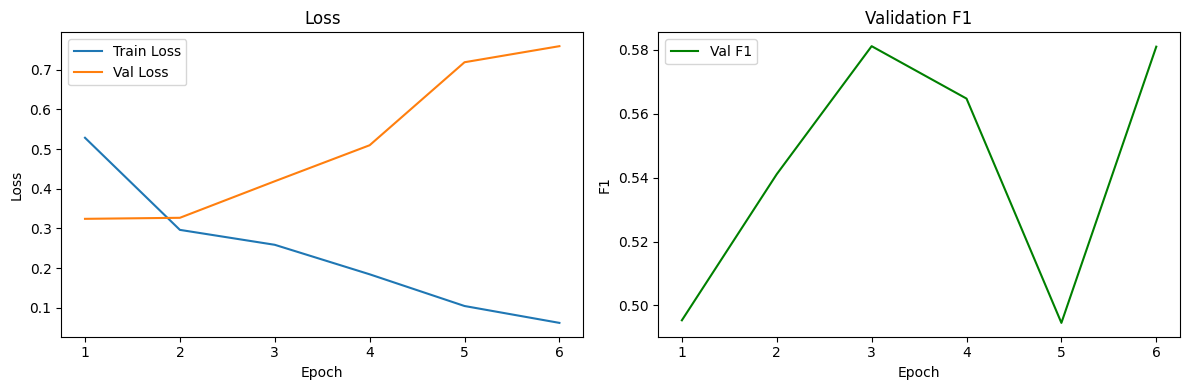

In [ ]:
# Plot results after completion of training

log_history = trainer.state.log_history
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

train_loss = [x["loss"] for x in train_logs]
eval_loss  = [x["eval_loss"] for x in eval_logs]
eval_f1    = [x["eval_f1"] for x in eval_logs]
epochs     = [x["epoch"] for x in eval_logs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, label="Train Loss")
ax1.plot(epochs, eval_loss, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.set_title("Loss")

ax2.plot(epochs, eval_f1, label="Val F1", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1")
ax2.legend()
ax2.set_title("Validation F1")

plt.tight_layout()
plt.show()